In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text
import matplotlib.pyplot as plt
import seaborn as sns
import os

print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
df = pd.read_csv('data/raw/online_retail.csv', encoding='latin-1')
print(f'Raw rows: {len(df):,}')

Raw rows: 541,909


In [3]:
df = df.dropna(subset=['CustomerID'])
print(f'After dropping missing CustomerID: {len(df):,}')

After dropping missing CustomerID: 406,829


In [4]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
print(f'After removing cancellations: {len(df):,}')


After removing cancellations: 397,924


In [5]:
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]
print(f'After removing negatives: {len(df):,}')

After removing negatives: 397,884


In [6]:
df = df.drop_duplicates()
print(f'After dropping duplicates: {len(df):,}')

After dropping duplicates: 392,692


In [7]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']
print(f'Columns now: {list(df.columns)}')


Columns now: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalAmount']


In [8]:
df = df[df['InvoiceDate'].dt.year == 2011]
print(f'After filtering to 2011: {len(df):,}')


After filtering to 2011: 367,022


In [9]:
df.to_csv('data/processed/orders_clean.csv', index=False)
print('Saved orders_clean.csv ✓')

Saved orders_clean.csv ✓


In [10]:
engine = create_engine('sqlite:///data/rfm.db')
df.to_sql('orders_clean', engine, if_exists='replace', index=False)
print('Loaded into SQLite ✓')

Loaded into SQLite ✓


/var/folders/d1/6l59j_vj6m1905v93yt8t7h80000gn/T/ipykernel_3387/812628053.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


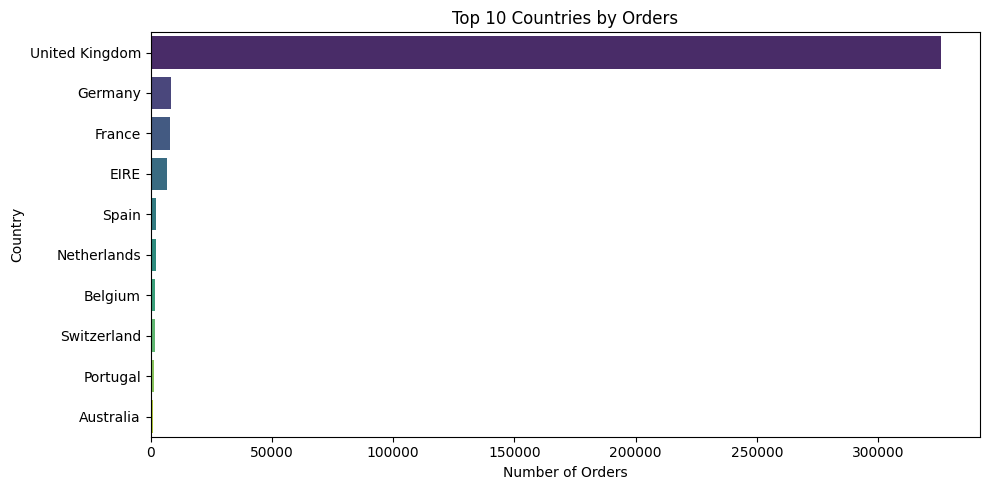

Saved ✓


In [11]:
top_countries = df['Country'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Orders')
plt.xlabel('Number of Orders')
plt.tight_layout()
plt.savefig('dashboards/eda/top_countries.png')
plt.show()
print('Saved ✓')

/var/folders/d1/6l59j_vj6m1905v93yt8t7h80000gn/T/ipykernel_3387/1820328734.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='magma')


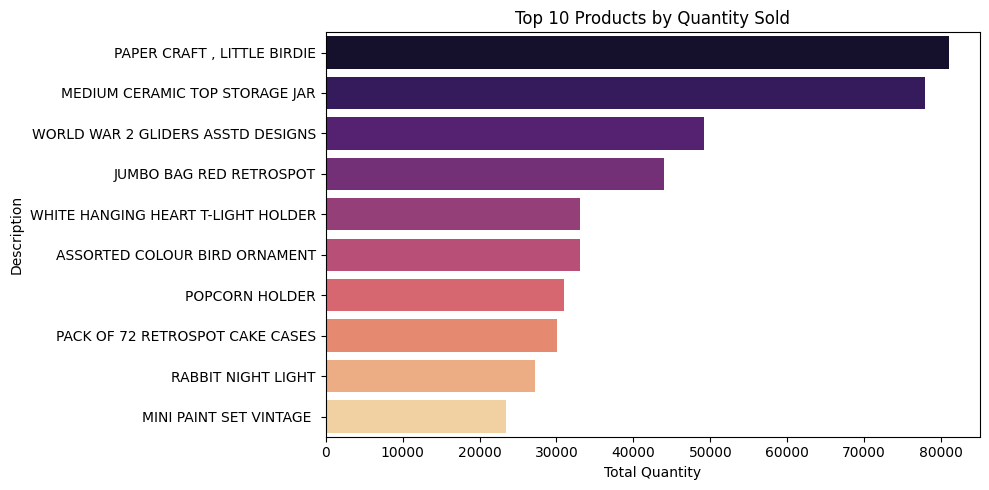

Saved ✓


In [12]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_products.values, y=top_products.index, palette='magma')
plt.title('Top 10 Products by Quantity Sold')
plt.xlabel('Total Quantity')
plt.tight_layout()
plt.savefig('dashboards/eda/top_products.png')
plt.show()
print('Saved ✓')

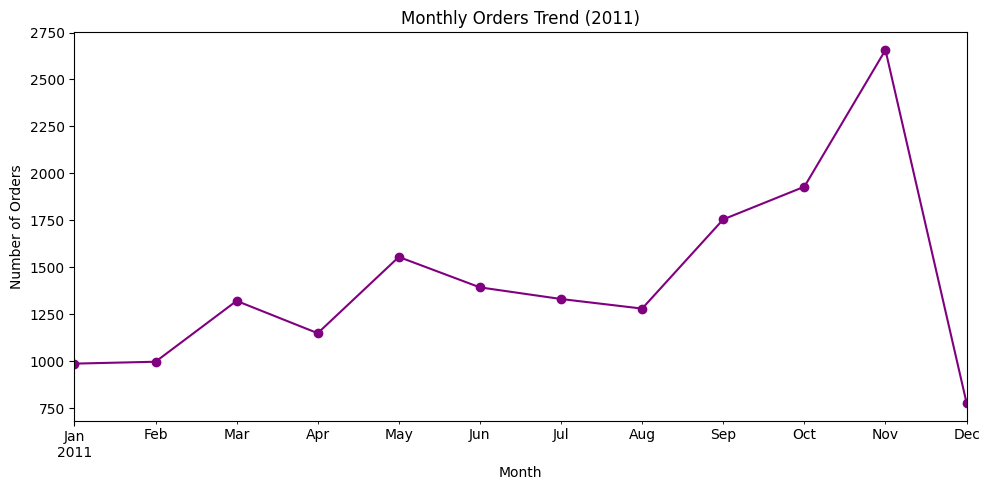

Saved ✓


In [13]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly = df.groupby('Month')['InvoiceNo'].nunique()

plt.figure(figsize=(10, 5))
monthly.plot(kind='line', marker='o', color='purple')
plt.title('Monthly Orders Trend (2011)')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('dashboards/eda/monthly_trend.png')
plt.show()
print('Saved ✓')


/var/folders/d1/6l59j_vj6m1905v93yt8t7h80000gn/T/ipykernel_3387/3964161247.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_revenue.values, y=top_revenue.index, palette='coolwarm')


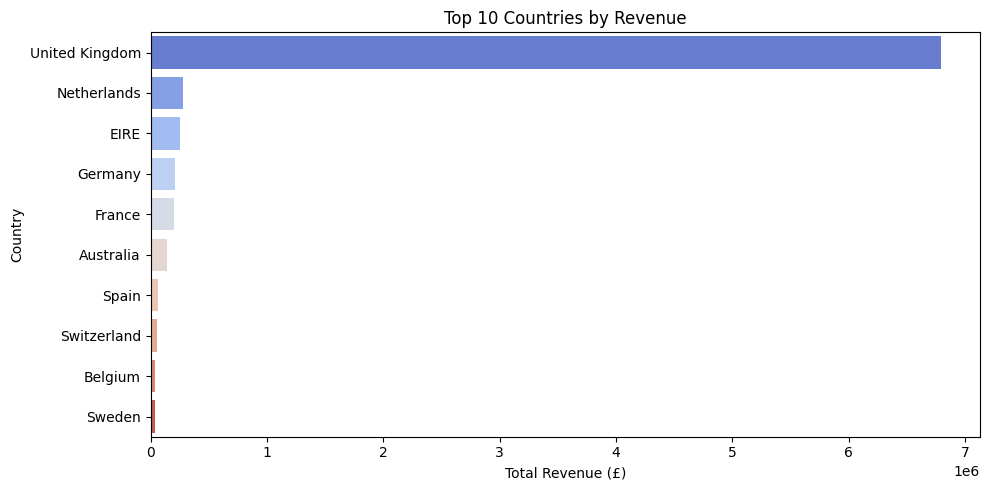

Saved ✓


In [14]:
top_revenue = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_revenue.values, y=top_revenue.index, palette='coolwarm')
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig('dashboards/eda/revenue_by_country.png')
plt.show()
print('Saved ✓')

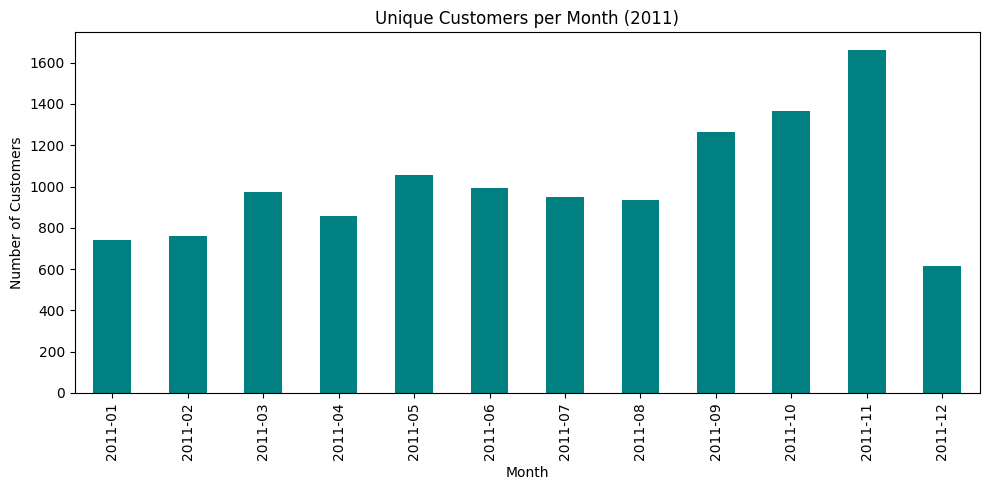

Saved ✓


In [15]:
monthly_customers = df.groupby('Month')['CustomerID'].nunique()

plt.figure(figsize=(10, 5))
monthly_customers.plot(kind='bar', color='teal')
plt.title('Unique Customers per Month (2011)')
plt.xlabel('Month')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('dashboards/eda/monthly_customers.png')
plt.show()
print('Saved ✓')

In [16]:
findings = """
## EDA Findings

- The majority of orders come from the United Kingdom by a large margin.
- The top selling products are decorative and gift items.
- Orders peak in November 2011, likely due to Christmas shopping season.
- Revenue is heavily concentrated in the UK market.
- Unique customers grow steadily through mid-2011 before a spike in Q4.
"""

print(findings)


## EDA Findings

- The majority of orders come from the United Kingdom by a large margin.
- The top selling products are decorative and gift items.
- Orders peak in November 2011, likely due to Christmas shopping season.
- Revenue is heavily concentrated in the UK market.
- Unique customers grow steadily through mid-2011 before a spike in Q4.

